In [7]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import palette_light

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts

from sparcl.client import SparclClient
from astropy.table import Table

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


hamann_fits_path = "data/local/ERQs_core_all_MNRAS.fits"
search_log_path = "data/local/hamann-objects-desi-search-log.json"

In [2]:
hamann_data = Table.read("data/local/ERQs_core_all_MNRAS.fits").to_pandas() #pd.read_csv(hamann_erq_path,index_col=0)

hamann_data["sdss_name"] = hamann_data["sdss_name"].astype("string")

match_df = pd.read_json(search_log_path)
match_df = match_df[["SDSS_id","best_match_id"]].copy()
match_df["SDSS_id"] = match_df["SDSS_id"].str[1:]

match_df = match_df.rename(columns={"best_match_id":"targetid", "SDSS_id":"sdss_name"})

hamann_erq = hamann_data.merge(match_df,on="sdss_name",how="left")

hamann_erq

,sdss_name,Plate,MJD,FiberID,ThingID,z_dr12,i,i_err,W3,W3_snr,...,kt75,kt80,rew_di,rewe_di,fwhm_di,qflag,rew_nv,frat_nv_civ,nvflag,targetid
0,000610.67+121501.2,5649,55912,288,220079389,2.309943,22.101451,0.160805,14.087,35.1,...,0.455485,0.372288,102.007661,6.075000,4508.508813,0,192.343862,1.880187,0,39628078766358575
1,000746.19+122223.9,6176,56264,194,221814072,2.429000,21.314343,0.079014,16.369,7.0,...,0.383122,0.284162,213.628344,4.754235,2550.825969,0,64.601598,0.388502,0,39628078770555722
2,002400.25+245031.9,6279,56243,28,328146826,2.809255,21.556824,0.090767,15.522,14.6,...,0.455389,0.372201,134.821509,10.120908,3694.810492,0,205.776721,2.455813,0,39628365275075274
3,004713.21+264024.7,6286,56301,800,342571394,2.563943,20.435463,0.038392,15.714,13.2,...,0.413071,0.325082,100.642397,5.476974,3662.920844,0,141.614347,1.923201,0,Not found
4,005044.95-021217.6,4370,55534,980,60738765,2.254000,21.473060,0.078552,16.760,4.6,...,0.262998,0.193256,148.782256,6.993491,5445.426756,0,46.553849,0.609687,0,39627730584601174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,223754.52+065026.6,5058,56208,124,172688138,2.608809,21.960453,0.106963,16.169,3.9,...,0.440905,0.356129,136.337135,3.430820,1318.560329,0,109.072962,1.034336,0,39627953214063409
93,225438.30+232714.5,6588,56536,390,315135318,3.087494,22.010175,0.120658,16.552,5.3,...,0.442837,0.358143,354.839828,22.560964,4906.586551,0,211.097222,0.660819,0,Not found
94,232326.17-010033.1,4210,55444,93,75229201,2.356070,22.410147,0.200206,15.218,19.1,...,0.454002,0.370693,260.264938,4.465699,4186.298391,0,565.970265,2.160131,0,39627766454292268
95,232828.47+044346.8,4283,55864,592,153323514,2.563872,21.532625,0.144071,16.066,9.3,...,0.437510,0.352179,356.552346,4.328203,1575.355245,0,122.280344,0.373535,0,39627905315113841


In [3]:
client = SparclClient()

idxs = [int(x) for x in hamann_erq["targetid"].head(10) if x != "Not found"]

output_fields = ['specid', 'redshift', 'wavelength', 'flux', 'ivar', 'spectype', 'targetid', 'redshift_warning']

spectra = client.retrieve_by_specid(idxs, dataset_list=["DESI-DR1"], include=output_fields)

spectra_df = pd.DataFrame(spectra.data[1:])
spectra_df

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


,targetid,redshift,spectype,redshift_warning,specid,flux,ivar,wavelength,_dr
0,39628078766358575,2.199301,QSO,0,39628078766358575,"[6.083261489868164, 7.300170421600342, 5.58030...","[0.09443012624979019, 0.11103168874979019, 0.1...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
1,39627730584601174,1.782655,QSO,0,39627730584601174,"[0.4372713565826416, 2.111987352371216, -4.080...","[0.07881371676921844, 0.0627162829041481, 0.06...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
2,39628365275075274,2.837482,QSO,0,39628365275075274,"[0.7628244161605835, -1.0635453462600708, 0.83...","[0.33674854040145874, 0.3539333641529083, 0.37...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
3,39628504643403849,2.360326,QSO,0,39628504643403849,"[0.29033735394477844, 3.1691737174987793, -2.4...","[0.05054178088903427, 0.09497752040624619, 0.0...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
4,39627706643513715,2.536830,QSO,0,39627706643513715,"[3.230962038040161, -2.0705037117004395, 2.608...","[0.17553436756134033, 0.1668706238269806, 0.18...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
5,39628078770555722,2.430429,QSO,0,39628078770555722,"[1.2459850311279297, -3.726759195327759, -1.50...","[0.0447843037545681, 0.056199029088020325, 0.0...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1
6,39627640176382892,2.452858,QSO,0,39627640176382892,"[2.040266513824463, 2.7940256595611572, -1.077...","[0.13237154483795166, 0.1565820425748825, 0.15...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1


In [5]:
spectra_df["targetid"] = spectra_df["targetid"].astype("string")
spectra = spectra_df.merge(hamann_erq[["targetid","ThingID","sdss_name"]],on="targetid",how="left")

spectra

,targetid,redshift,spectype,redshift_warning,specid,flux,ivar,wavelength,_dr,ThingID,sdss_name
0,39628078766358575,2.199301,QSO,0,39628078766358575,"[6.083261489868164, 7.300170421600342, 5.58030...","[0.09443012624979019, 0.11103168874979019, 0.1...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1,220079389,000610.67+121501.2
1,39627730584601174,1.782655,QSO,0,39627730584601174,"[0.4372713565826416, 2.111987352371216, -4.080...","[0.07881371676921844, 0.0627162829041481, 0.06...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1,60738765,005044.95-021217.6
2,39628365275075274,2.837482,QSO,0,39628365275075274,"[0.7628244161605835, -1.0635453462600708, 0.83...","[0.33674854040145874, 0.3539333641529083, 0.37...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1,328146826,002400.25+245031.9
3,39628504643403849,2.360326,QSO,0,39628504643403849,"[0.29033735394477844, 3.1691737174987793, -2.4...","[0.05054178088903427, 0.09497752040624619, 0.0...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1,379358920,020932.15+312202.7
4,39627706643513715,2.536830,QSO,0,39627706643513715,"[3.230962038040161, -2.0705037117004395, 2.608...","[0.17553436756134033, 0.1668706238269806, 0.18...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1,53077112,014111.13-031852.5
5,39628078770555722,2.430429,QSO,0,39628078770555722,"[1.2459850311279297, -3.726759195327759, -1.50...","[0.0447843037545681, 0.056199029088020325, 0.0...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1,221814072,000746.19+122223.9
6,39627640176382892,2.452858,QSO,0,39627640176382892,"[2.040266513824463, 2.7940256595611572, -1.077...","[0.13237154483795166, 0.1565820425748825, 0.15...","[3600.0, 3600.8, 3601.6000000000004, 3602.4000...",DESI-DR1,41285937,005233.24-055653.5


False None


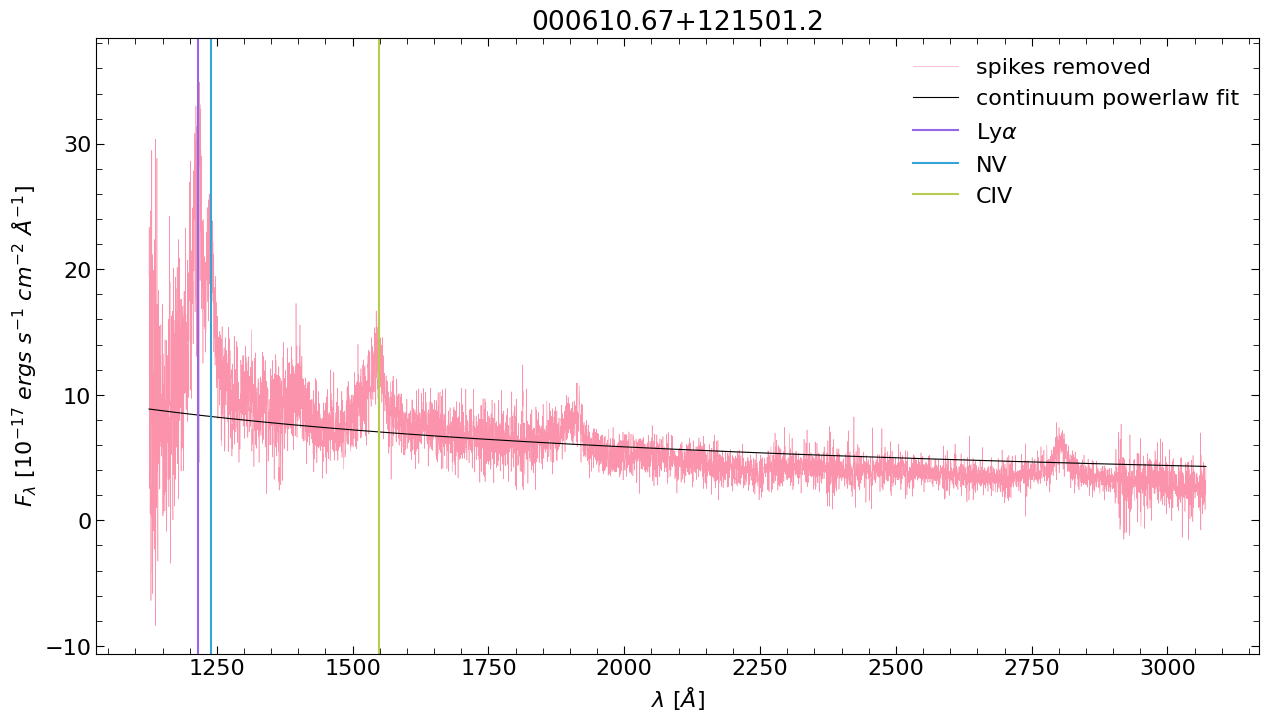

False None


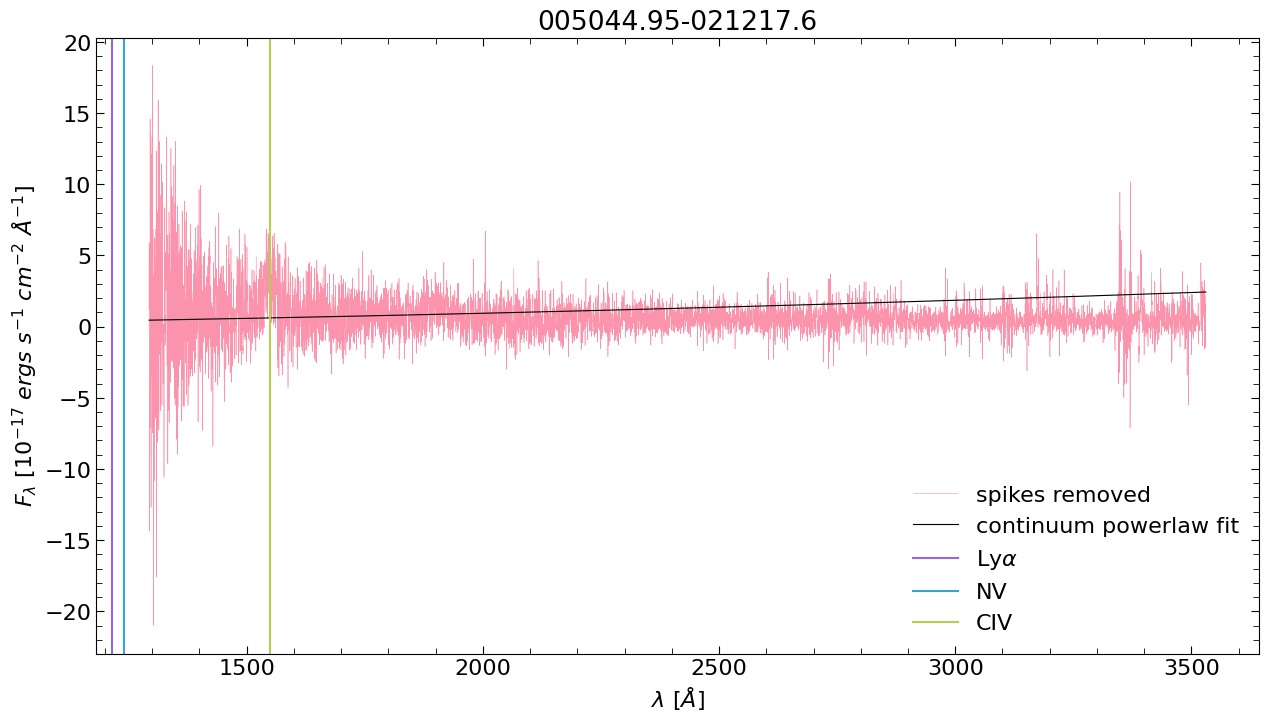

False None


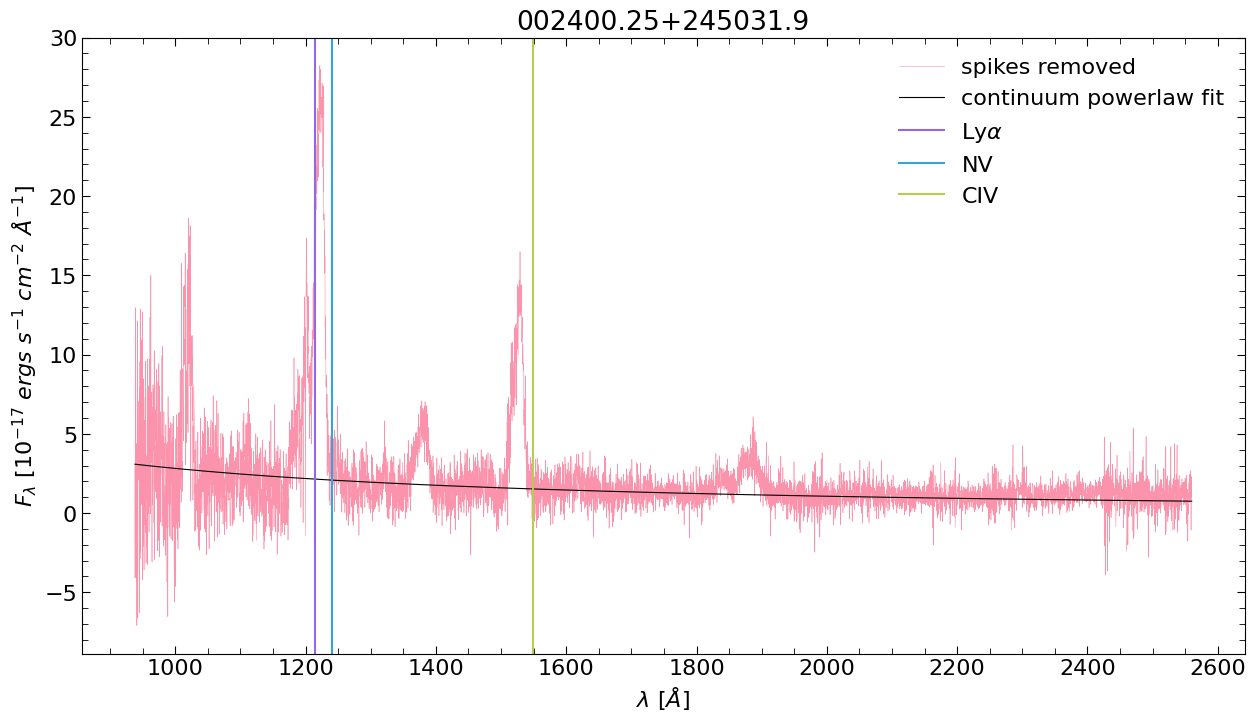

False None


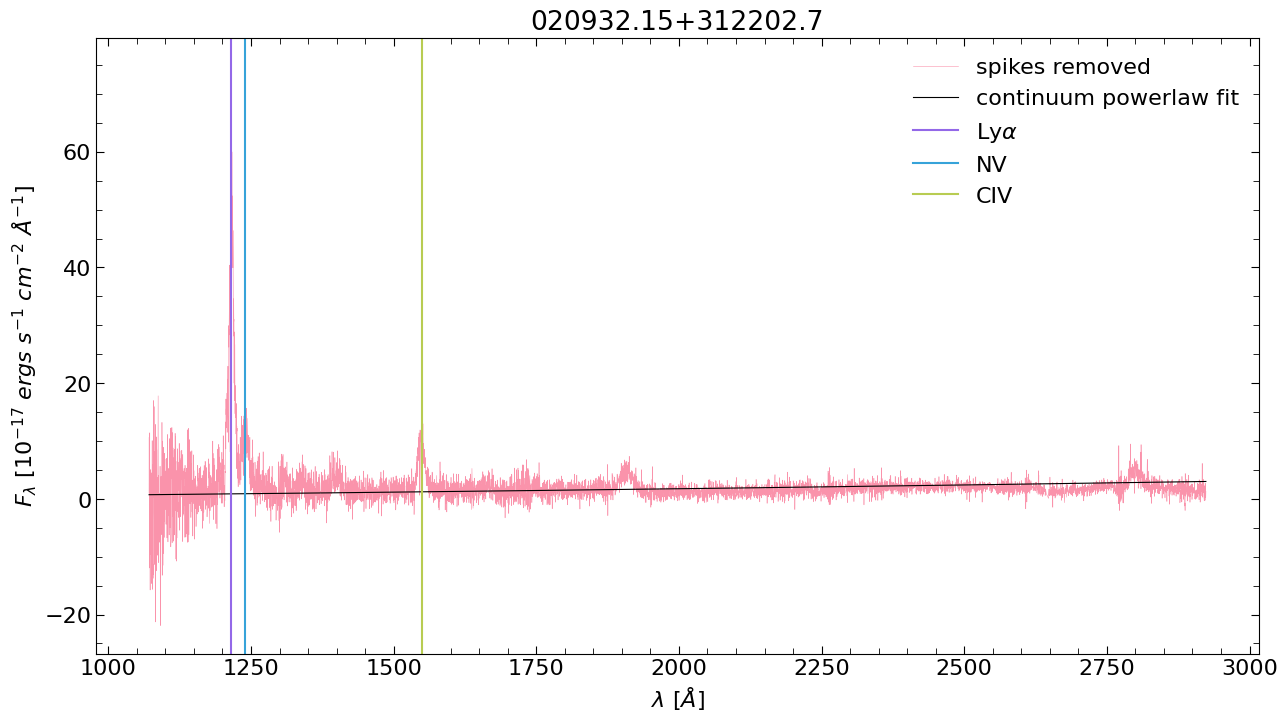

False None


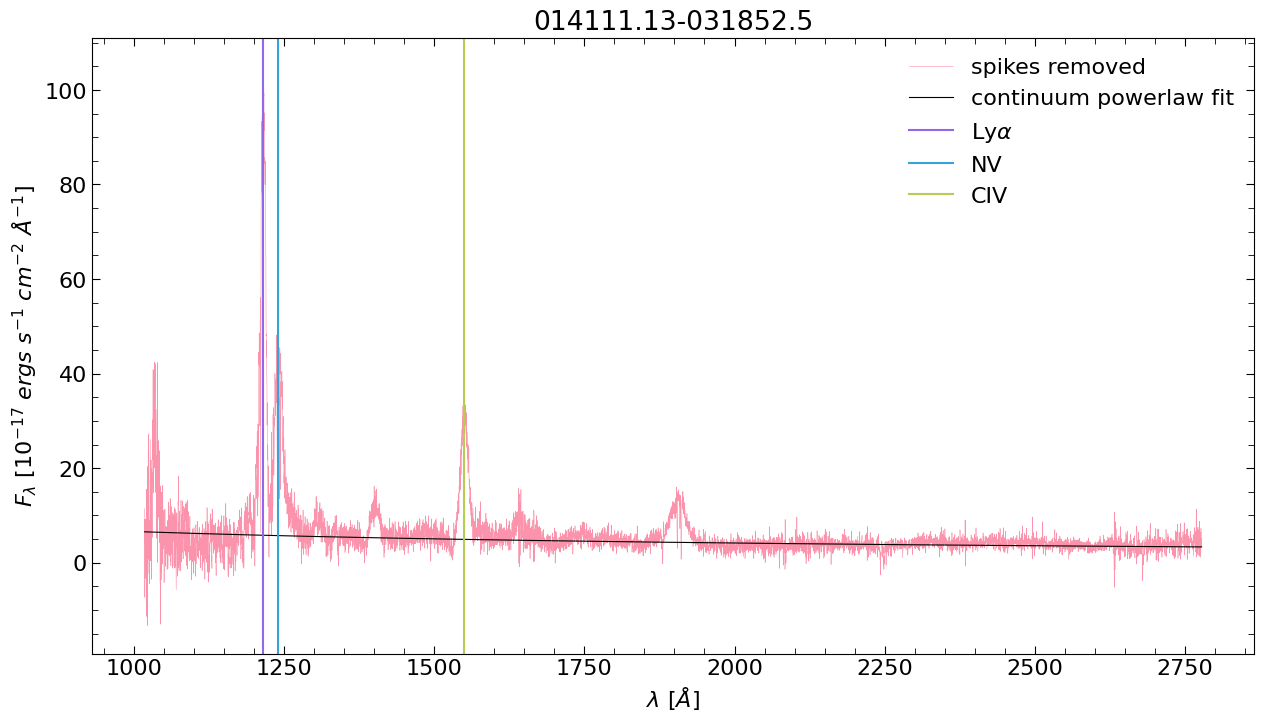

False None


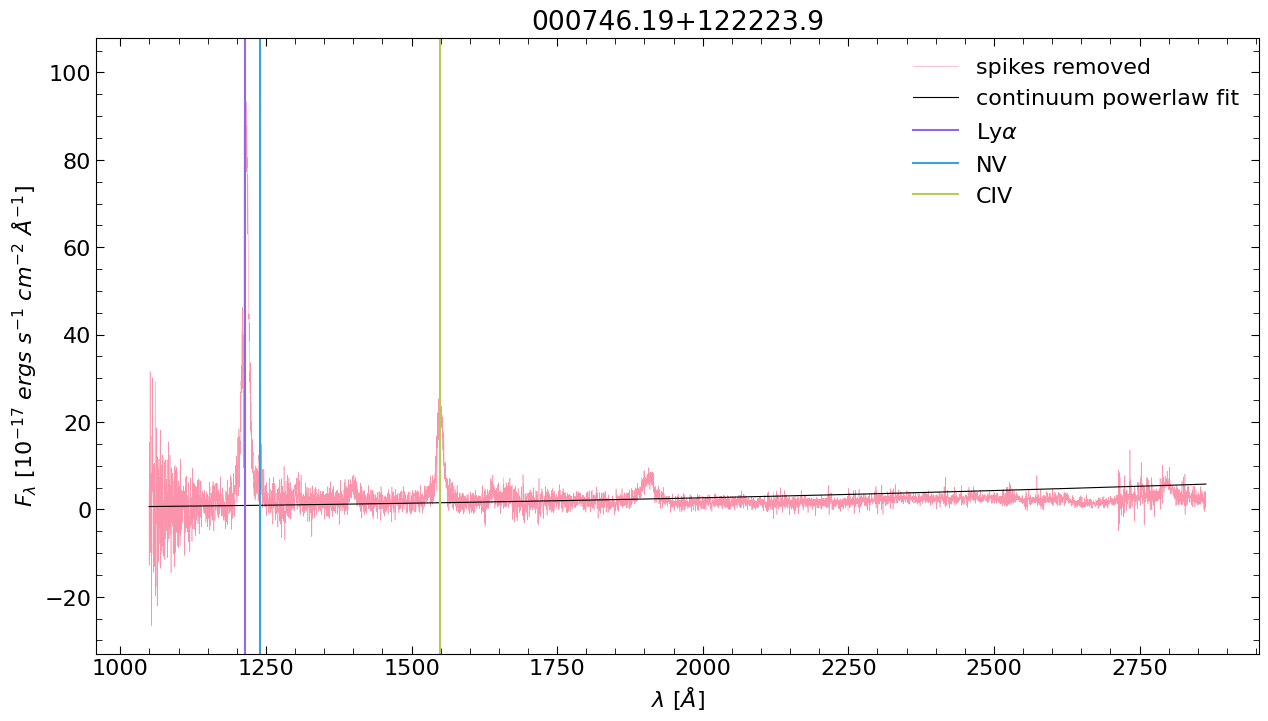

False None


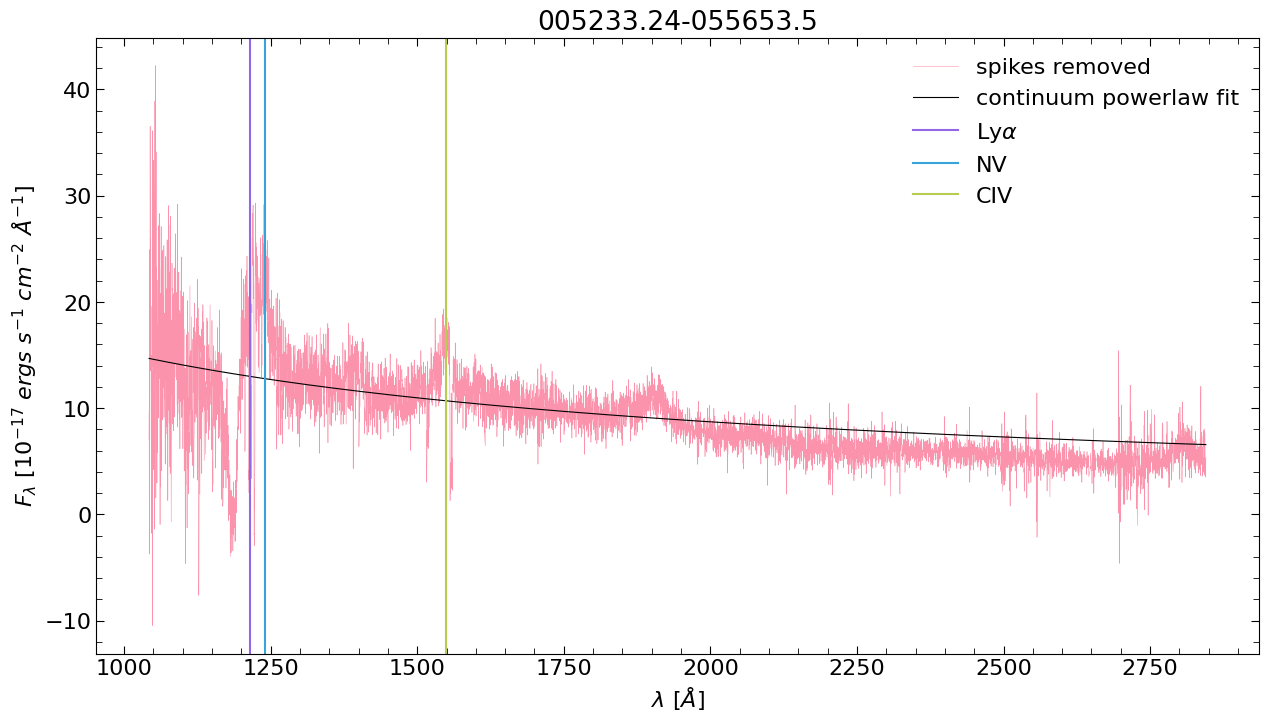

In [6]:
for idx in range(len(spectra_df)):
    lam = np.array(spectra_df["wavelength"][idx])
    flux = np.array(spectra_df["flux"][idx])
    ivar = np.array(spectra_df["ivar"][idx])
    z = spectra_df["redshift"][idx]

    lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

    flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar)

    result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar)

    rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result)

    print(rejected, reason)

    plot_spectrum(lam, flux_clean, title=f"{spectra['sdss_name'][idx]}",flux_label="spikes removed", add_smoothed=False, additional_flux=continuum, additional_flux_label="continuum powerlaw fit",line_lambda=[1215,1240,1549], line_label=[r"Ly$\alpha$","NV","CIV"])